# Cube cell example notebook

## Initial set up

#### Get the imports and change the directory

In [92]:
# Set the directory
import os
os.chdir("../..")

In [93]:
from System.system import System
from Visualize.visualize import *
import matplotlib.pyplot as plt 
%matplotlib inline

### Set the atoms' values and create the system

In [151]:
# Set the base atom
atoms = [[[0, 0, 0], 0.1]]

# Set the other atoms' distance from the origin and radii
dist = 7
rad = 5

# Create a list of locations and radii for the system object to parse
atoms += [[[dist, 0, 0], rad -1], [[-dist, 0, 0], rad], [[0, dist, 0], rad], [[0, -dist, 0], rad], [[0, 0, dist], rad],
          [[0, 0, -dist], rad]]

# Create the system
sys = System(atoms)

### Build the network

In [152]:
# Build the system with a minimum distance setting. 
sys.net.build(min_dist=0.5)

Building Network:  ########## 100 %
Network Built
Building Surfaces: ########## 100 %
Surfaces Built


### Analyze the system

In [153]:
sys.analyze()

## Plot the results

<IPython.core.display.Javascript object>


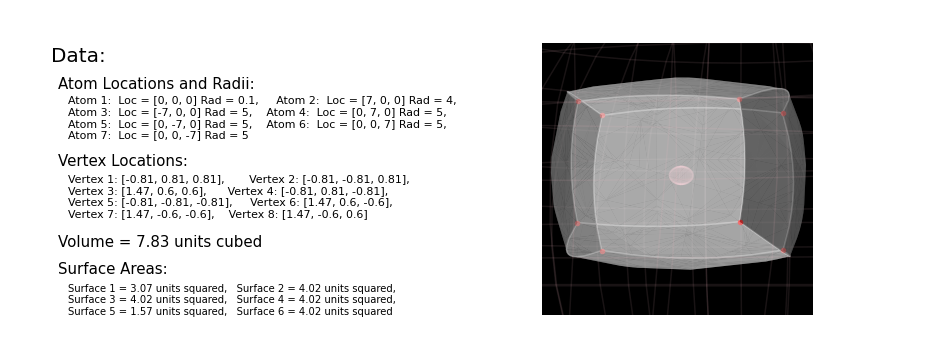

In [154]:
%matplotlib notebook
# Set up the plot
fig = plt.figure(figsize=(13, 5))

# Setup the text
text = fig.add_subplot(121, )
text.text(-.20, 0.93, "Data:", fontsize=20)
text.text(-0.18, .83, "Atom Locations and Radii:", fontsize=15)
# List the location of the atoms

text.text(-0.15, .65, "Atom 1:  Loc = {} Rad = {},     Atom 2:  Loc = {} Rad = {},\nAtom 3:  Loc = {} Rad = {},    Atom 4:  Loc = {} Rad = {},\nAtom 5:  Loc = {} Rad = {},    Atom 6:  Loc = {} Rad = {},\nAtom 7:  Loc = {} Rad = {}"         .format(sys.atoms[0].loc, sys.atoms[0].rad, sys.atoms[1].loc, sys.atoms[1].rad, sys.atoms[2].loc, sys.atoms[2].rad, sys.atoms[3].loc, sys.atoms[3].rad, sys.atoms[4].loc, sys.atoms[4].rad,
                  sys.atoms[5].loc, sys.atoms[5].rad, sys.atoms[6].loc, sys.atoms[6].rad), fontsize=11)
# List the location of the vertices
text.text(-0.18, .55, "Vertex Locations:", fontsize=15)
round_verts = sys.net.verts.copy()
round_verts = [[round(vert.loc[0], 2), round(vert.loc[1], 2), round(vert.loc[2], 2)] for vert in round_verts]
text.text(-0.15, .36, "Vertex 1: {},       Vertex 2: {},\nVertex 3: {},      Vertex 4: {}, \nVertex 5: {},     Vertex 6: {}, \nVertex 7: {},    Vertex 8: {}"
          .format(round_verts[0], round_verts[1], round_verts[2], round_verts[3], round_verts[4], round_verts[5], round_verts[6], round_verts[7]), fontsize=11)

# Print the volume and the surface area of the surfaces
text.text(-0.18, 0.25, "Volume = {} units cubed".format(round(sys.net.atoms[0].cell_vol, 2)), fontsize=15)
text.text(-0.18, 0.15, "Surface Areas: ", fontsize=15)
text.text(-0.15, 0.0, "Surface 1 = {} units squared,   Surface 2 = {} units squared,\nSurface 3 = {} units squared,   Surface 4 = {} units squared,\nSurface 5 = {} units squared,   Surface 6 = {} units squared"
          .format(round(sys.net.surfs[0].sa, 2), round(sys.net.surfs[1].sa, 2), round(sys.net.surfs[2].sa, 2), round(sys.net.surfs[3].sa, 2), round(sys.net.surfs[4].sa, 2), round(sys.net.surfs[5].sa, 2)))

text.axis('off')

ax = fig.add_subplot(122, projection="3d")
# Plot the elements of the network
plot_atoms(sys.atoms, fig=fig, ax=ax, dfo=2, alpha=0.1)
plot_verts(sys.net.verts, fig=fig, ax=ax, colors=['r' for i in range(8)])
plot_edges(sys.net.edges, fig=fig, ax=ax)
plot_surfs(sys.net.surfs, simps=True, fig=fig, ax=ax, dfo=10)

plt.show()